<a href="https://colab.research.google.com/github/soleildayana/Celestial-Mechanics/blob/main/TrompoHamiltoniano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de trompo siguiendo el formalismo hamiltoniano y sus ecuaciones de movimiento

Soleil Dayana Niño Murcia

Mecánica Celeste 2026-1

### 1. Importación de Librerías
Utilizaremos `numpy` para el cálculo numérico, `scipy.integrate` para resolver las ecuaciones diferenciales y `matplotlib` para la visualización 3D.

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

### 2. Formalismo Lagrangiano y Cuadraturas
Partimos del Lagrangiano para un trompo simétrico en términos de los ángulos de Euler $(\theta, \phi, \psi)$:

$$L = \frac{1}{2} I_1 (\dot{\theta}^2 + \dot{\phi}^2 \sin^2 \theta) + \frac{1}{2} I_3 (\dot{\psi} + \dot{\phi} \cos \theta)^2 - mgl \cos \theta$$

Identificamos las **cuadraturas** (constantes de movimiento) debido a que $\phi$ y $\psi$ son coordenadas cíclicas:

1.  **Momento angular en el eje z (precesión):**
    $$p_\phi = \frac{\partial L}{\partial \dot{\phi}} = (I_1 \sin^2 \theta + I_3 \cos^2 \theta) \dot{\phi} + I_3 \dot{\psi} \cos \theta = \text{constante}$$
2.  **Momento angular en el eje de simetría (rotación propia):**
    $$p_\psi = \frac{\partial L}{\partial \dot{\psi}} = I_3 (\dot{\psi} + \dot{\phi} \cos \theta) = \text{constante}$$
3.  **Energía Total (Hamiltoniano):**
    $$E = \frac{1}{2} I_1 \dot{\theta}^2 + V_{eff}(\theta) = \text{constante}$$

### Ecuaciones de Movimiento Reducidas
Usando las constantes $p_\phi$ y $p_\psi$, despejamos $\dot{\phi}$ y $\dot{\psi}$:

$$\dot{\phi} = \frac{p_\phi - p_\psi \cos \theta}{I_1 \sin^2 \theta}$$
$$\dot{\psi} = \frac{p_\psi}{I_3} - \dot{\phi} \cos \theta$$

Sustituyendo en la ecuación de Lagrange para $\theta$:
$$I_1 \ddot{\theta} = I_1 \dot{\phi}^2 \sin \theta \cos \theta - I_3 (\dot{\psi} + \dot{\phi} \cos \theta) \dot{\phi} \sin \theta + mgl \sin \theta$$

In [7]:
def lagrangiano_trompo(t, y, I1, I3, m, g, l, p_phi, p_psi):
    theta, dot_theta, phi, psi = y

    # Evitar singularidades
    sin_theta = np.sin(theta)
    if abs(sin_theta) < 1e-6: sin_theta = 1e-6
    cos_theta = np.cos(theta)

    # Derivadas de las coordenadas cíclicas a partir de las constantes de movimiento
    d_phi = (p_phi - p_psi * cos_theta) / (I1 * sin_theta**2)
    d_psi = (p_psi / I3) - d_phi * cos_theta

    # Ecuación de movimiento para theta (aceleración)
    # Basada en d/dt(dL/d_dot_theta) - dL/d_theta = 0 (E-L)
    d2_theta = (d_phi**2 * sin_theta * cos_theta) - (I3 / I1) * (d_psi + d_phi * cos_theta) * d_phi * sin_theta + (m * g * l / I1) * sin_theta

    return [dot_theta, d2_theta, d_phi, d_psi]

### 3. Configuración y Simulación
Definimos los parámetros físicos y las condiciones iniciales para observar la precesión y nutación. Además, se calculan los periodos de precesión, nutación y rotación.

In [8]:
# Parámetros físicos
m, g, l = 1.0, 9.81, 0.5
I1, I3 = 0.5, 0.2

# Condiciones iniciales
theta0 = np.deg2rad(30)  # 30 grados de inclinación
phi0, psi0 = 0.0, 0.0
dot_psi = 50.0           # Rotación propia rápida (rad/s)
dot_phi = 2.0            # Precesión inicial
dot_theta = 0.5          # Empujón inicial para ver nutación

In [9]:
# Cálculo de momentos conjugados iniciales (conservados)
p_psi = I3 * (dot_psi + dot_phi * np.cos(theta0))
p_phi = I1 * dot_phi * np.sin(theta0)**2 + p_psi * np.cos(theta0)
p_theta = I1 * dot_theta

y0 = [theta0, dot_theta, phi0, psi0] # Corregido orden del vector de estado para el Lagrangiano
t_span = (0, 15)
t_eval = np.linspace(0, 15, 2000)

sol = solve_ivp(lagrangiano_trompo, t_span, y0, t_eval=t_eval, args=(I1, I3, m, g, l, p_phi, p_psi))

# Cálculo del Periodo de Nutación (T_theta) mediante evento
def evento_nutacion(t, y, I1, I3, m, g, l, p_phi, p_psi):
    if t < 0.05: return -1.0 # Ignorar el inicio exacto
    return y[0] - theta0
evento_nutacion.terminal = True
evento_nutacion.direction = 1

sol_n = solve_ivp(lagrangiano_trompo, (0, 5), y0, events=evento_nutacion, args=(I1, I3, m, g, l, p_phi, p_psi))
if sol_n.t_events[0].size > 0:
    valor_periodo_nutacion = sol_n.t_events[0][0]
    print(f"Periodo de Nutación (T_theta): {valor_periodo_nutacion:.4f} segundos")

Periodo de Nutación (T_theta): 0.3163 segundos


In [10]:
def evento_precesion(t, y, I1, I3, m, g, l, p_phi, p_psi):
    return y[2] - 2*np.pi
evento_precesion.terminal = True

# Simulación para encontrar T_phi
sol_p = solve_ivp(lagrangiano_trompo, (0, 50), y0, events=evento_precesion, args=(I1, I3, m, g, l, p_phi, p_psi))

if sol_p.t_events[0].size > 0:
    valor_periodo_precesion = sol_p.t_events[0][0]
    print(f"Periodo de Precesión (T_phi): {valor_periodo_precesion:.4f} segundos")
else:
    print("No se detectó un ciclo completo de precesión en el tiempo dado.")

Periodo de Precesión (T_phi): 12.7333 segundos


In [11]:
# Cálculo numérico del periodo de rotación propia (T_psi)
# Basado en la velocidad angular dot_psi inicial
valor_periodo_rotacion = (2 * np.pi) / dot_psi

print(f"Periodo de Rotación Propia (T_psi): {valor_periodo_rotacion:.4f} segundos")

Periodo de Rotación Propia (T_psi): 0.1257 segundos


### 4. Visualización 3D de la Trayectoria
Convertimos los ángulos de Euler a coordenadas cartesianas para ver el camino que recorre el eje del trompo.

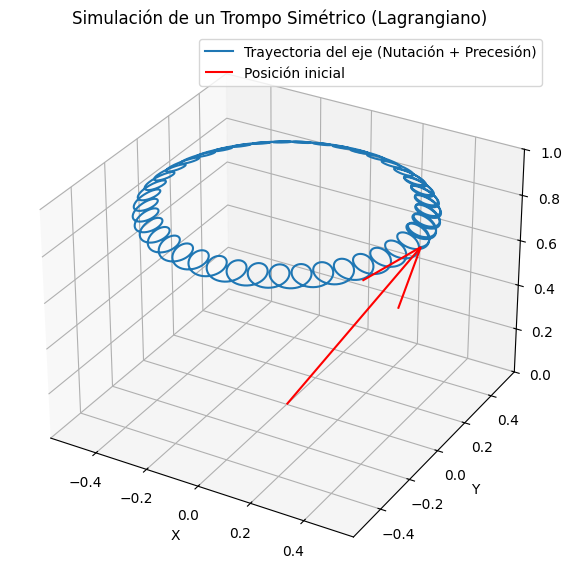

In [12]:
theta_vec = sol.y[0]
phi_vec = sol.y[2] # Cambiado de 1 a 2 para coincidir con el nuevo vector de estado

# Coordenadas del extremo del eje (l=1 para normalizar la visualización)
x = np.sin(theta_vec) * np.cos(phi_vec)
y = np.sin(theta_vec) * np.sin(phi_vec)
z = np.cos(theta_vec)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x, y, z, label='Trayectoria del eje (Nutación + Precesión)')
ax.quiver(0, 0, 0, x[0], y[0], z[0], color='r', label='Posición inicial')
ax.set_zlim(0, 1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Simulación de un Trompo Simétrico (Lagrangiano)")
ax.legend()
plt.show()

### 5. Animación Interactiva con Plotly
Creamos una animación donde se muestra el cuerpo del trompo (barra negra) y su trayectoria (azul con transparencia).

In [13]:
# Ajustamos el paso para mantener suficiente detalle pero mejorar el rendimiento
step = 4
t_anim = t_eval[::step]
x_anim, y_anim, z_anim = x[::step], y[::step], z[::step]

# Crear la figura base
fig = go.Figure(
    data=[
        # Trayectoria (estela)
        go.Scatter3d(x=x_anim, y=y_anim, z=z_anim,
                     mode='lines',
                     line=dict(color='cyan', width=2),
                     opacity=0.4,
                     name='Trayectoria'),
        # Cuerpo del trompo (Barra)
        go.Scatter3d(x=[0, x_anim[0]], y=[0, y_anim[0]], z=[0, z_anim[0]],
                     mode='lines+markers',
                     line=dict(color='red', width=8),
                     marker=dict(size=[0, 25], color='red'),
                     name='Cuerpo del Trompo')
    ],
    layout=go.Layout(
        template="plotly_dark",
        scene=dict(
            xaxis=dict(range=[-0.8, 0.8], backgroundcolor="black"),
            yaxis=dict(range=[-0.8, 0.8], backgroundcolor="black"),
            zaxis=dict(range=[0, 1], backgroundcolor="black"),
            aspectmode='cube'
        ),
        updatemenus=[dict(type='buttons', buttons=[dict(
            label='Simular en vivo',
            method='animate',
            args=[None, {"frame": {"duration": 20, "redraw": True}, "fromcurrent": True, "transition": {"duration": 0}}]
        )])]
    ),
    frames=[go.Frame(
        data=[go.Scatter3d(x=x_anim[:i], y=y_anim[:i], z=z_anim[:i]),
              go.Scatter3d(x=[0, x_anim[i]], y=[0, y_anim[i]], z=[0, z_anim[i]])]
    ) for i in range(1, len(t_anim))]
)

fig.show()